In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


In [3]:
df =pd.read_csv(r'D:\iec\ass1\python\portfolio2\66634-ev-data\Electric_Vehicle_Population_Data.csv')
print(f"columns :list{df.columns}")
print(df.isnull().sum())



columns :listIndex(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='str')
VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base M

In [4]:
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
})
BLUE    = '#378ADD'
GREEN   = '#1D9E75'
CORAL   = '#D85A30'
PINK    = '#D4537E'
PURPLE  = '#7F77DD'
AMBER   = '#BA7517'
PALETTE = [BLUE, GREEN, CORAL, PINK, PURPLE, AMBER, '#0F6E56', '#639922', '#D4537E', '#888780']
C_BEV    = '#00D4FF'
C_PHEV   = '#FF6B35'
C_ACCENT = '#7DF9FF'
C_DARK   = '#0A0E1A'
C_CARD   = '#111827'
C_GRID   = 'rgba(255,255,255,0.06)'
C_TEXT   = '#E2E8F0'
C_SUB    = '#94A3B8'
 
FONT_TITLE = 'Rajdhani'
FONT_BODY  = 'IBM Plex Mono'
 
google_fonts = (
    "https://fonts.googleapis.com/css2?"
    "family=Rajdhani:wght@400;600;700&"
    "family=IBM+Plex+Mono:wght@400;500&display=swap")

In [35]:
duplicates = df.duplicated().sum()
print(duplicates)


0


In [5]:
total = df['Electric Vehicle Type'].notna().sum()
Bev_count = (df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)').sum()
Phev_count  = (df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)').sum()
Bevp = Bev_count/total*100
Phevp = Phev_count/total*100
top_make = df['Make'].value_counts().idxmax()
top_county = df['County'].value_counts().idxmax()
top_City = df['City'].value_counts().idxmax()
top_model = df['Model'].value_counts().idxmax()

print("Bev Total EVs:", Bev_count)
print("Phev Total EVs:", Phev_count)
print("Bev%: ", Bevp)
print("Phev%: ", Phevp)
print("Top Maker: ", top_make)
print("Top Model: ",top_model)
print("Top City: ", top_City)
print("Top County: ", top_county)



Bev Total EVs: 139210
Phev Total EVs: 38656
Bev%:  78.26678510789021
Phev%:  21.73321489210979
Top Maker:  TESLA
Top Model:  MODEL Y
Top City:  Seattle
Top County:  King


In [6]:
ev_counts = df['Electric Vehicle Type'].value_counts()
ev_counts.index=['Battery Electric Vehicle (BEV)','Plug-in Hybrid Electric Vehicle (PHEV)']

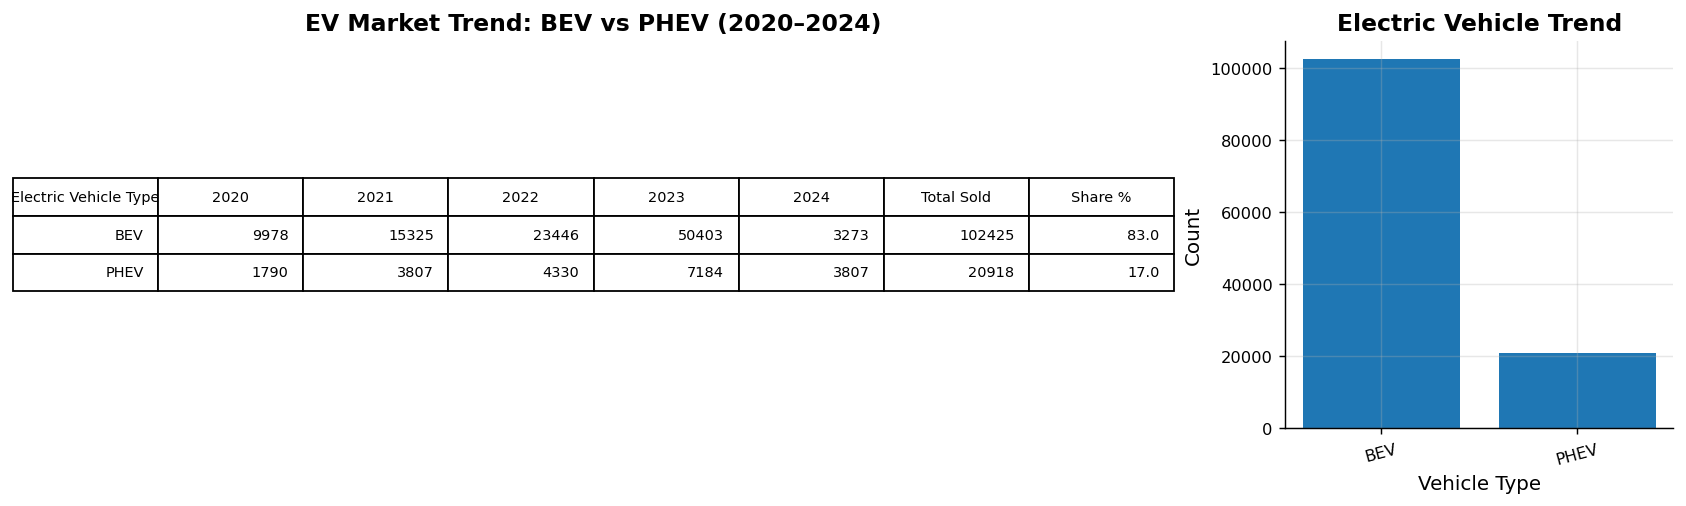

In [36]:
# Filter only required years
filtered_df = df[df['Model Year'].isin([2020, 2021, 2022, 2023, 2024])]

filtered_df['Electric Vehicle Type'] = filtered_df['Electric Vehicle Type'].replace({
    'Battery Electric Vehicle (BEV)': 'BEV',
    'Plug-in Hybrid Electric Vehicle (PHEV)': 'PHEV'
})
# Group by EV Type and Model Year
sales_table = (
    filtered_df.groupby(['Electric Vehicle Type', 'Model Year'])
    .size()
    .reset_index(name='Count')
)

# Pivot years into columns
pivot_table = sales_table.pivot(
    index='Electric Vehicle Type',
    columns='Model Year',
    values='Count'
).fillna(0)

# Convert to integer
pivot_table = pivot_table.astype(int)

# Total sold ONLY for included years
pivot_table['Total Sold'] = (
    pivot_table[2020] +
    pivot_table[2021] +
    pivot_table[2022] +
    pivot_table[2023] +
    pivot_table[2024]
)

# Share % ONLY for included years
grand_total = pivot_table['Total Sold'].sum()

pivot_table['Share %'] = (
    pivot_table['Total Sold'] / grand_total * 100
).round(1)

# Convert index into column
pivot_table = pivot_table.reset_index()

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 4),
    gridspec_kw={'width_ratios': [2.3, 1]}
)

# TABLE
axes[0].axis('off')

table = axes[0].table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.3, 1.8)

axes[0].set_title("EV Market Trend: BEV vs PHEV (2020–2024)")


# Bar Chart
axes[1].bar(
    pivot_table['Electric Vehicle Type'],
    pivot_table['Total Sold']
)

axes[1].set_title("Electric Vehicle Trend")
axes[1].set_xlabel("Vehicle Type")
axes[1].set_ylabel("Count")

axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

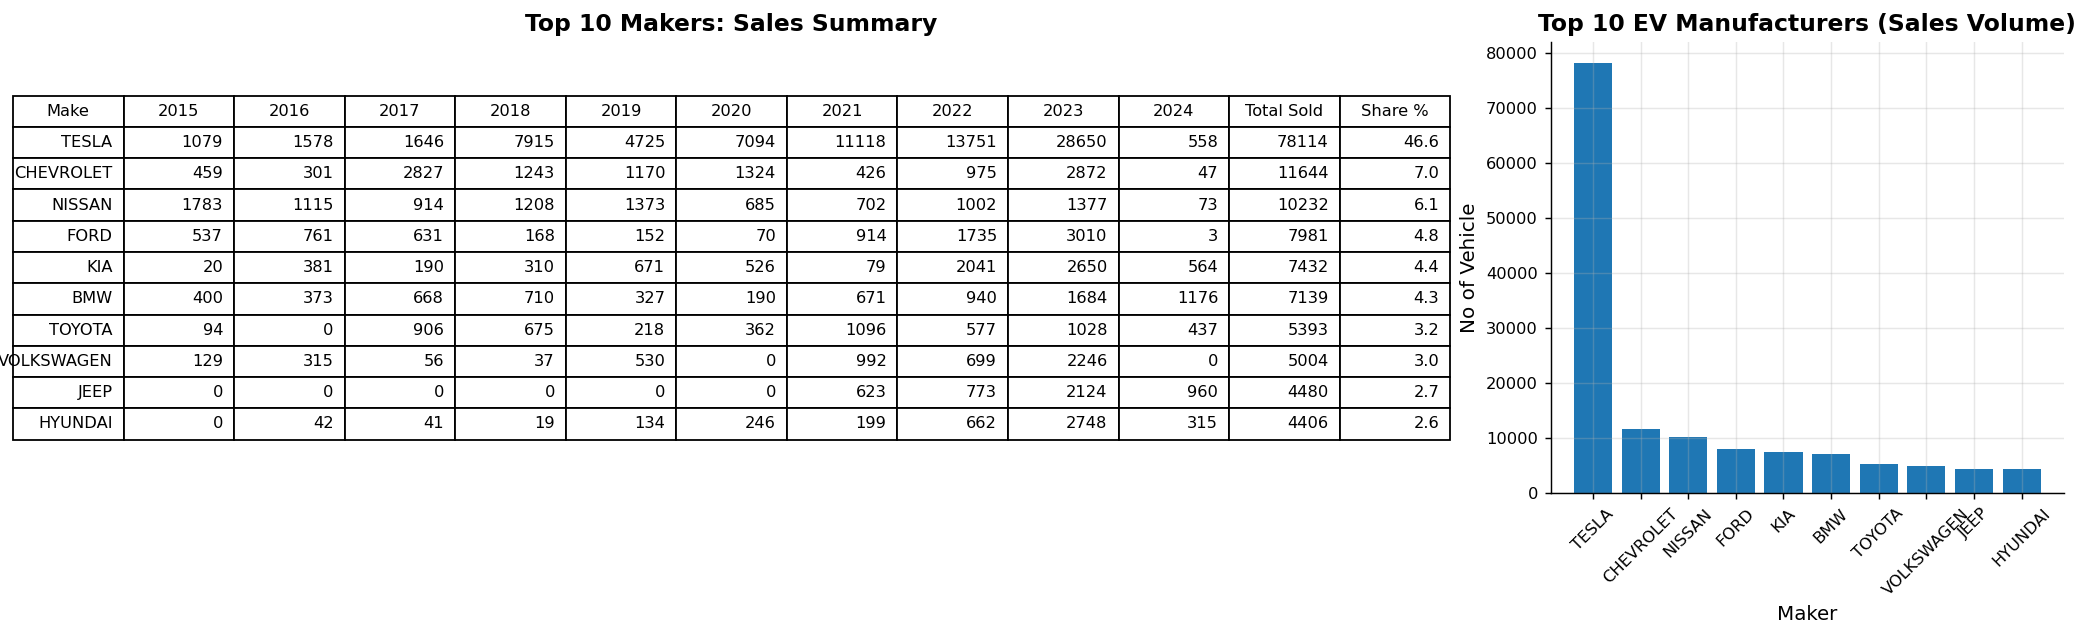

In [41]:
# Create figure with more space for table and smaller chart
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5),  # shorter height
    gridspec_kw={'width_ratios': [2, 1]}  # table wider, chart smaller
)

# TABLE
axes[0].axis('off')

table = axes[0].table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.4, 1.6)  # wider table cells

axes[0].set_title("Top 10 Makers: Sales Summary")


# BAR CHART (smaller width)
axes[1].bar(
    pivot_table['Make'],
    pivot_table['Total Sold']
)

axes[1].set_title("Top 10 EV Manufacturers (Sales Volume)")
axes[1].set_xlabel("Maker")
axes[1].set_ylabel("No of Vehicle")

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

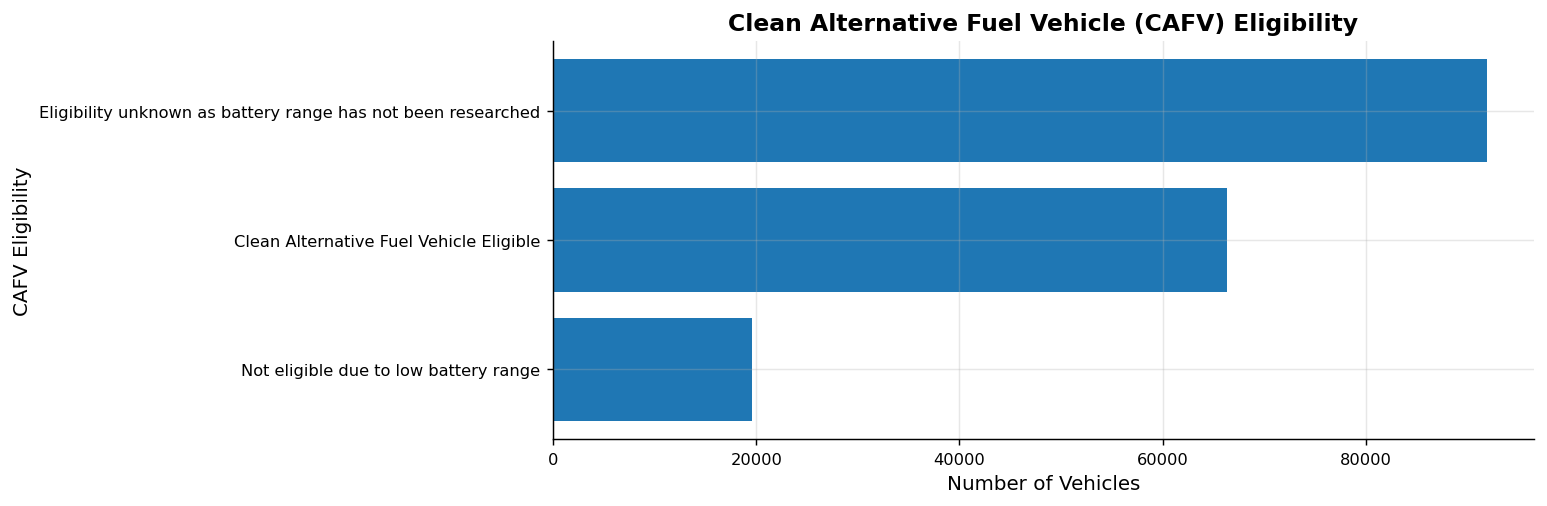

In [16]:
caf = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] \
        .value_counts() \
        .sort_values()

plt.figure(figsize=(12,4))

plt.barh(
    caf.index,
    caf.values
)

plt.title("Clean Alternative Fuel Vehicle (CAFV) Eligibility")
plt.xlabel("Number of Vehicles")
plt.ylabel("CAFV Eligibility")

plt.tight_layout()
plt.show()

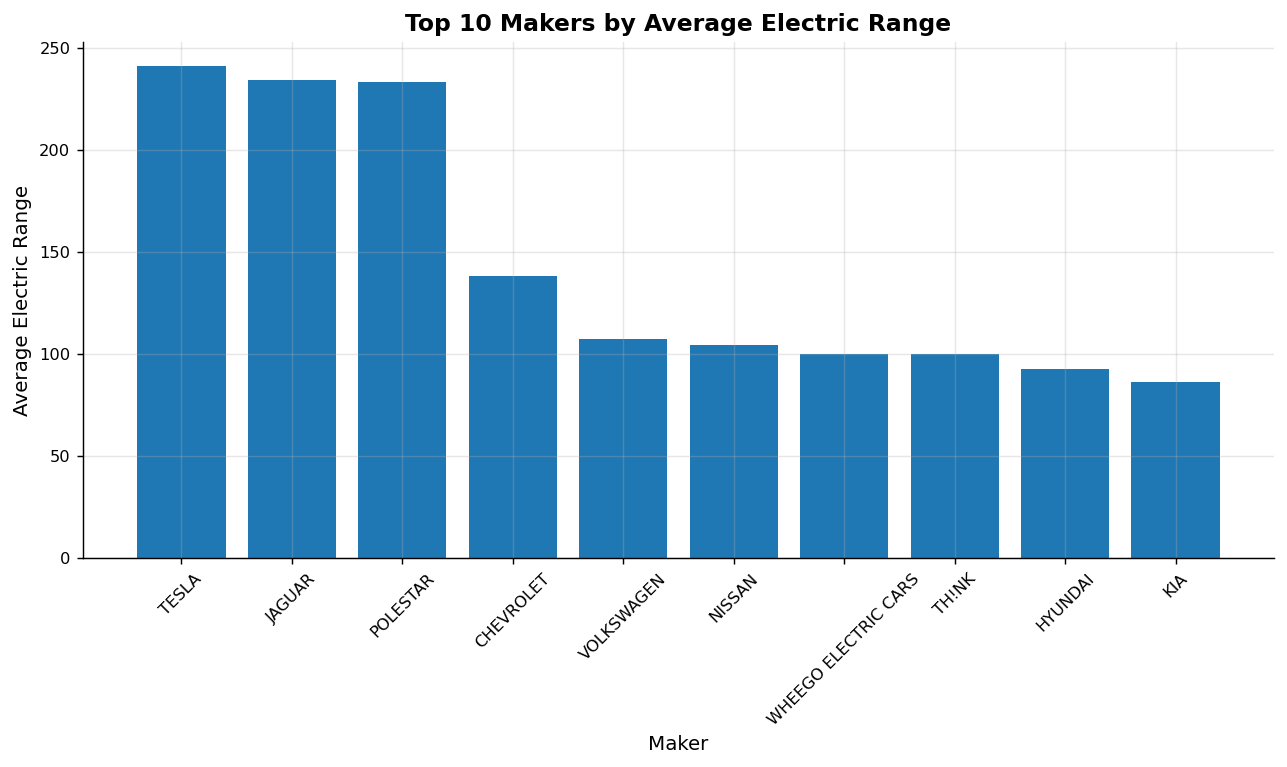

In [17]:
# Exclude 0 values first
df_filtered = df[df['Electric Range'] > 0]

# Average Electric Range by Make
range_by_make = (
    df_filtered.groupby('Make')['Electric Range']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    range_by_make.index,
    range_by_make.values
)

plt.title("Top 10 Makers by Average Electric Range")
plt.xlabel("Maker")
plt.ylabel("Average Electric Range")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

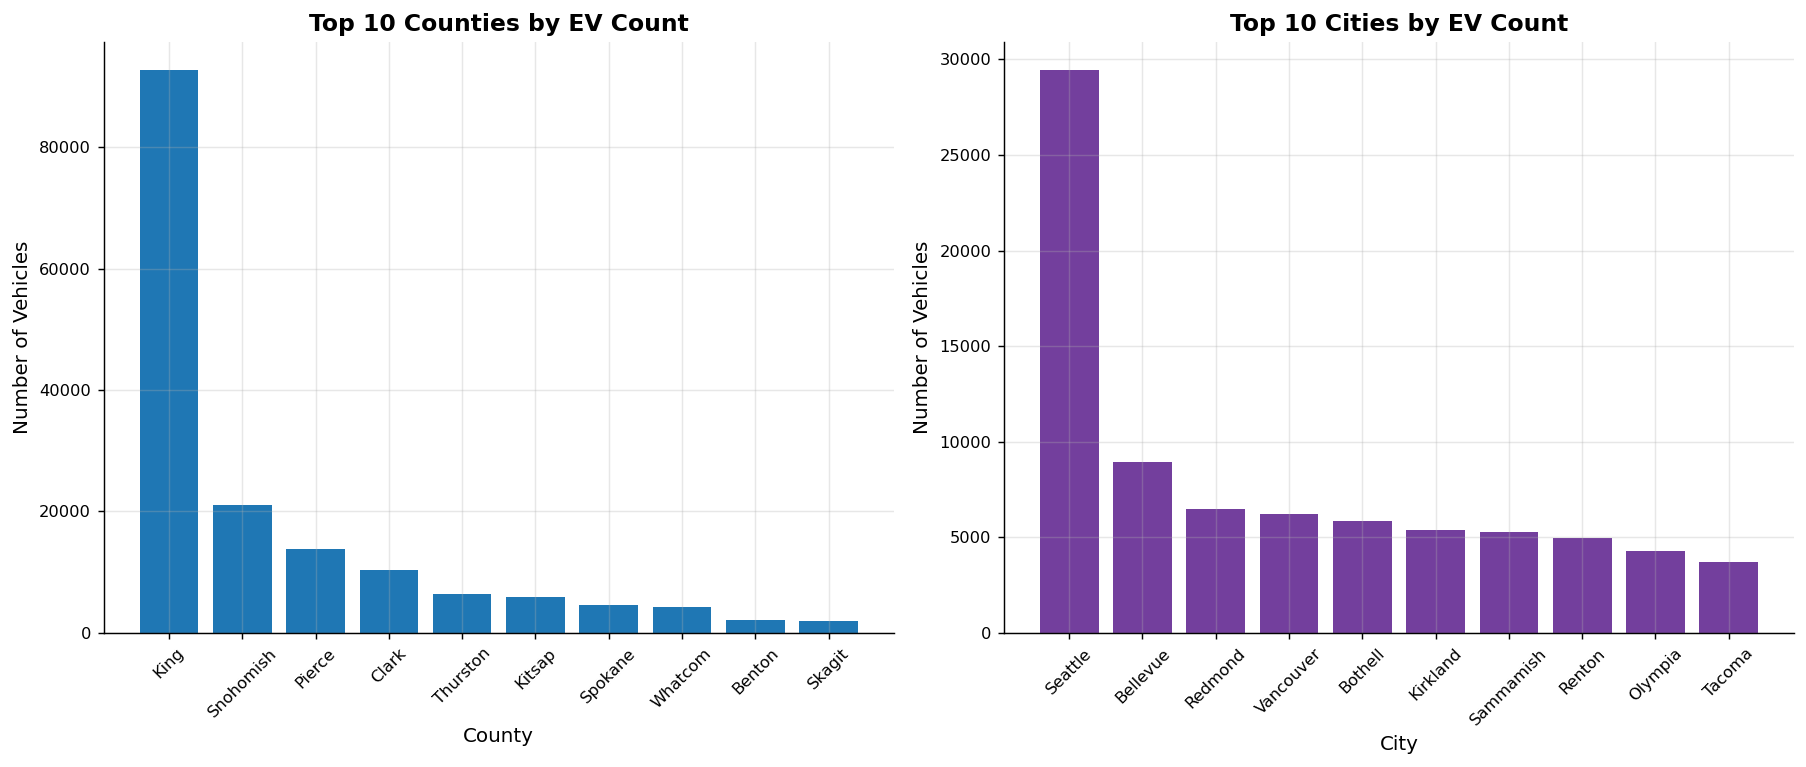

In [18]:
top_counties = df['County'].value_counts().head(10)
top_cities = df['City'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ------------------ Counties ------------------
axes[0].bar(
    top_counties.index,
    top_counties.values
)

axes[0].set_title("Top 10 Counties by EV Count")
axes[0].set_xlabel("County")
axes[0].set_ylabel("Number of Vehicles")
axes[0].tick_params(axis='x', rotation=45)

# ------------------ Cities ------------------
axes[1].bar(
    top_cities.index,
    top_cities.values,
    alpha=0.7
)
axes[1].bar(top_cities.index, top_cities.values, color='purple', alpha=0.6)

axes[1].set_title("Top 10 Cities by EV Count")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of Vehicles")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
range_by_make = (
    df[df['Electric Range'] > 0]
    .groupby('Make')['Electric Range']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

In [14]:
bev_by_city = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']['City'].value_counts().head(10)
phev_by_city = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']['City'].value_counts().head(10)

comparison_city_df = pd.DataFrame({
    'BEV': bev_by_city,
    'PHEV': phev_by_city
}).fillna(0)

bev_by_county = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']['County'].value_counts().head(10)
phev_by_county = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']['County'].value_counts().head(10)

comparison_county_df = pd.DataFrame({
    'BEV': bev_by_county,
    'PHEV': phev_by_county
}).fillna(0)

comparison_city_df = comparison_city_df.head(10)
comparison_county_df = comparison_county_df.head(10)

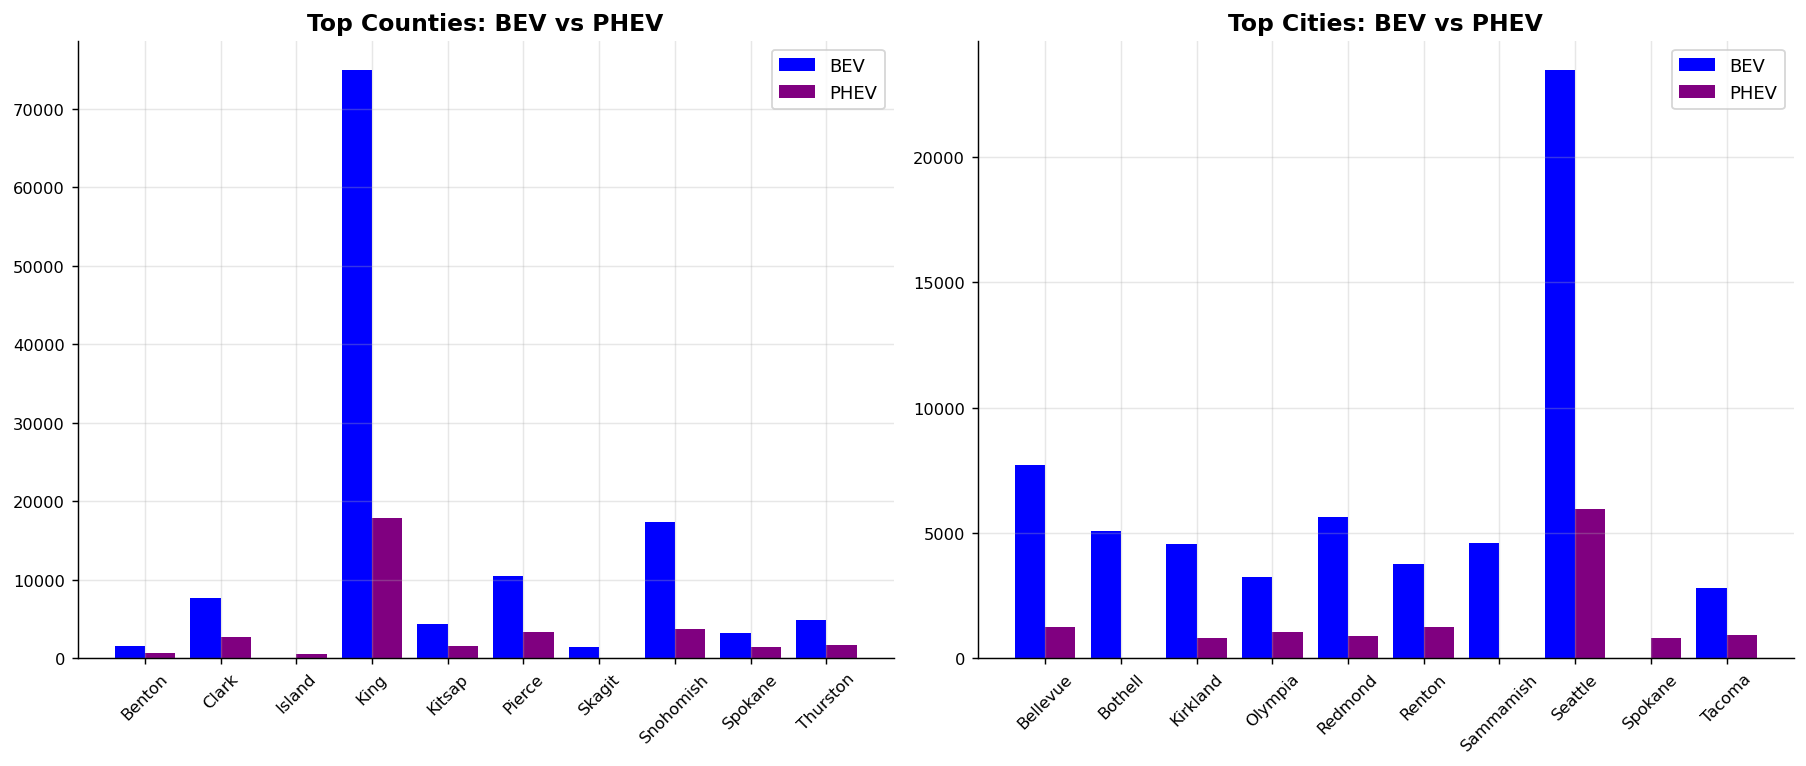

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------- COUNTIES ----------------
y = np.arange(len(comparison_county_df.index))
width = 0.4

axes[0].bar(y - width/2, comparison_county_df['BEV'], width, label='BEV', color='blue')
axes[0].bar(y + width/2, comparison_county_df['PHEV'], width, label='PHEV', color='purple')

axes[0].set_xticks(y)
axes[0].set_xticklabels(comparison_county_df.index, rotation=45)
axes[0].set_title("Top Counties: BEV vs PHEV")
axes[0].legend()

# ---------------- CITIES ----------------
x = np.arange(len(comparison_city_df.index))

axes[1].bar(x - width/2, comparison_city_df['BEV'], width, label='BEV', color='blue')
axes[1].bar(x + width/2, comparison_city_df['PHEV'], width, label='PHEV', color='purple')

axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_city_df.index, rotation=45)
axes[1].set_title("Top Cities: BEV vs PHEV")
axes[1].legend()

plt.tight_layout()
plt.show()

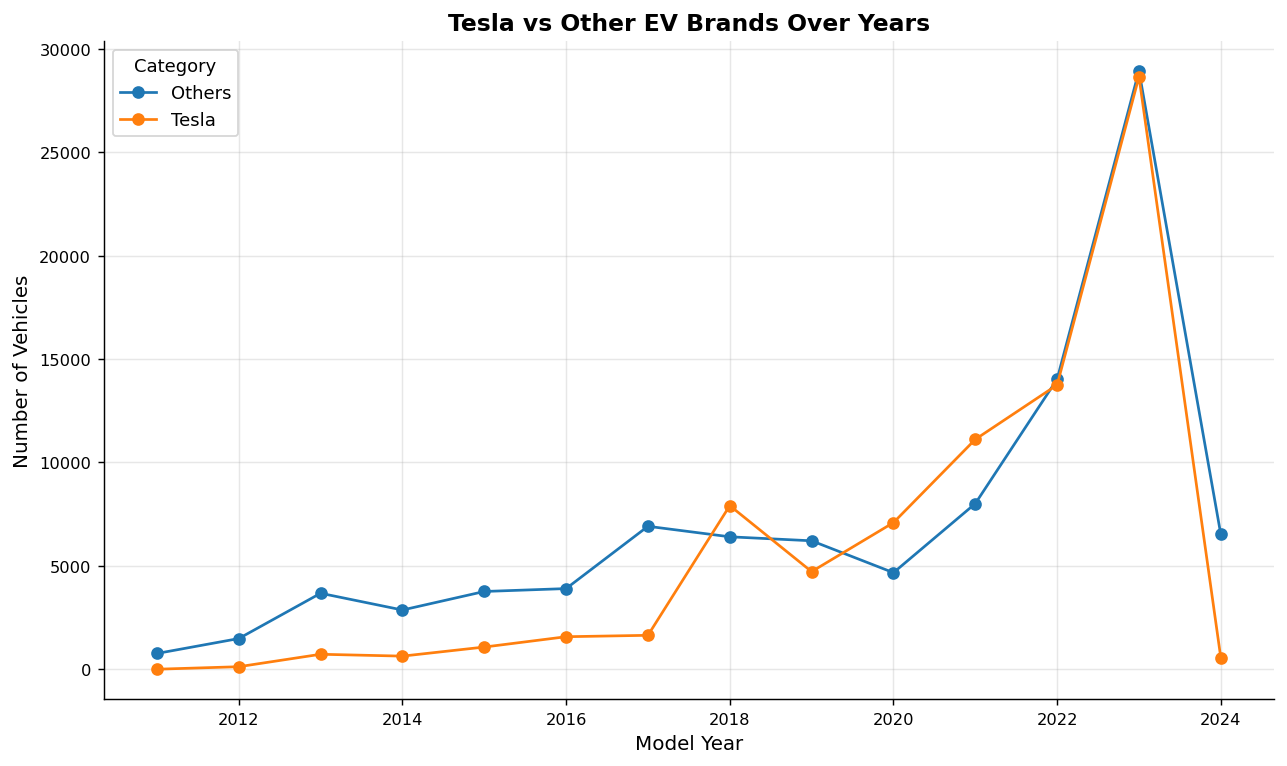

In [28]:
df['Category'] = df['Make'].apply(lambda x: 'Tesla' if x.upper() == 'TESLA' else 'Others')

comparison = df[df['Model Year'] > 2010].groupby(['Model Year', 'Category']).size().unstack()

comparison.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.title("Tesla vs Other EV Brands Over Years")

plt.legend(title="Category")
plt.tight_layout()
plt.show()

In [31]:
df['Category'] = df['Make'].apply(lambda x: 'Tesla' if x.upper() == 'TESLA' else 'Others')

tesla_vs_others = df['Category'].value_counts().reset_index()

tesla_vs_others.columns = ['Category', 'Number of Vehicles']

tesla_vs_others

,Category,Number of Vehicles
0,Others,98207
1,Tesla,79659
